# M8 · Calibration & Class Imbalance — Hands-on, Step by Tiny Step

**Companion to lesson M8. Written for someone new to ML.**

In M7 we built a model that predicts **pCTR** (a click probability) and saw that the ad
auction does `pCTR × bid`. That means the probability has to be **honest** — if the model
says `0.20`, clicks should really happen ~20% of the time. This notebook is about making
probabilities honest (**calibration**) and about what happens when the thing you're
predicting is **rare** (**class imbalance**), plus two real-world traps (**sparse slices**
and **delayed feedback**).

**What you'll do (each step has an explanation, logging, and a picture):**
- **Part A · Calibration:** reliability diagrams, the **ECE** number, why a good *ranking*
  can still be a *lying* probability, and two fixes — **Platt** and **isotonic**.
- **Part B · Class imbalance:** why *accuracy* lies when positives are rare, and how
  **class weights / focal loss / resampling** help (and why resampling then needs
  recalibration).
- **Part C · Sparse slices & delayed feedback:** why tiny groups need **shrinkage** and
  why fresh data looks falsely negative.

We use **scikit-learn** — the standard toolbox for calibration (the base model could be
anything, including the PyTorch models from M7). Runs in Colab with no installs. Run each
cell with **Shift+Enter**.

## Step 1 · Setup + a couple of helper functions

Two helpers we'll reuse:
- `reliability(...)` buckets predictions and returns, per bucket, the **average predicted**
  probability and the **actual** rate — the two things a reliability diagram plots.
- `ece(...)` turns those bucket gaps into **one number** (Expected Calibration Error).
Don't worry about the code yet — the next steps explain both with pictures.

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

def reliability(pred, actual, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    xs, ys, counts = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (pred >= lo) & (pred < hi)
        if m.sum():
            xs.append(pred[m].mean()); ys.append(actual[m].mean()); counts.append(int(m.sum()))
    return np.array(xs), np.array(ys), np.array(counts)

def ece(pred, actual, n_bins=10):
    xs, ys, counts = reliability(pred, actual, n_bins)
    return float(np.sum(counts / len(pred) * np.abs(ys - xs)))

print("helpers ready: reliability() and ece()")

helpers ready: reliability() and ece()


---
# Part A · Calibration

## Step 2 · What does "calibrated" mean? (make data with a KNOWN truth)

**Calibrated** = the number means what it says. A weather forecaster who says "70% rain"
should be right about 70% of the time. To check a model we need to know the *real*
probability, so (like M7) we build synthetic data where **we** set the true click
probability `true_p` for each impression, then flip a coin to get the click.

In [5]:
rng = np.random.default_rng(0)
N = 12000
x1, x2, x3 = rng.uniform(0,1,N), rng.uniform(0,1,N), rng.uniform(0,1,N)
true_p = 1 / (1 + np.exp(-(-1.0 + 2.5*x1 + 1.5*x2 - 1.0*x3)))   # the REAL click probability
y = (rng.random(N) < true_p).astype(int)                        # the click (0/1)

# split: train the model / hold out a "calibration" set / final test
tr, cal, te = slice(0, 7000), slice(7000, 9500), slice(9500, N)
print("impressions:", N, "| overall click rate:", round(y.mean(), 3))
print("true_p ranges from", round(true_p.min(),3), "to", round(true_p.max(),3))

impressions: 12000 | overall click rate: 0.605
true_p ranges from 0.126 to 0.952


## Step 3 · An **overconfident** model (ranks great, lies about probabilities)

Many real models — boosted trees, deep nets — come out **overconfident**: they push scores
too close to 0 and 1. We simulate that by *sharpening* the true probabilities. Crucially
this keeps the **ranking** identical (it's a monotone transform), so **AUC stays high** —
the model orders impressions perfectly, yet its numbers are wrong. That's the trap M8 is
about.

In [7]:
from sklearn.metrics import roc_auc_score
def logit(p): p = np.clip(p, 1e-6, 1-1e-6); return np.log(p/(1-p))

raw_all = 1 / (1 + np.exp(-2.2 * logit(true_p)))     # sharpen: same order, overconfident numbers
raw      = raw_all[te]                                # scores on the test set
raw_cal  = raw_all[cal]                               # scores on the calibration set

print("AUC (ranking quality):", round(roc_auc_score(y[te], raw), 3), "-> ranks fine")
print("ECE (calibration error):", round(ece(raw, y[te]), 3), "-> but the probabilities are OFF")

AUC (ranking quality): 0.724 -> ranks fine
ECE (calibration error): 0.127 -> but the probabilities are OFF


## Step 4 · The reliability diagram — *see* the miscalibration

Bucket impressions by predicted probability; for each bucket plot **predicted** (x) vs
**actual** rate (y). Honest = dots on the diagonal. An overconfident model bows **away**
from the line: where it predicts high it's too high, where it predicts low it's too low.

bucket-by-bucket (predicted vs actual):
  predicted 0.06 -> actual 0.20   (120 impressions)
  predicted 0.15 -> actual 0.32   (165 impressions)
  predicted 0.25 -> actual 0.40   (167 impressions)
  predicted 0.35 -> actual 0.48   (155 impressions)
  predicted 0.45 -> actual 0.53   (181 impressions)
  predicted 0.55 -> actual 0.49   (173 impressions)
  predicted 0.65 -> actual 0.59   (156 impressions)
  predicted 0.75 -> actual 0.61   (238 impressions)
  predicted 0.85 -> actual 0.69   (365 impressions)
  predicted 0.95 -> actual 0.82   (780 impressions)


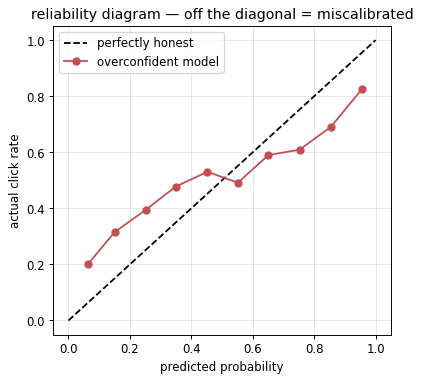

In [9]:
xs, ys, counts = reliability(raw, y[te])
plt.figure(figsize=(4.8, 4.6))
plt.plot([0,1],[0,1], "k--", label="perfectly honest")
plt.plot(xs, ys, "o-", color=RED, label="overconfident model")
plt.xlabel("predicted probability"); plt.ylabel("actual click rate")
plt.title("reliability diagram — off the diagonal = miscalibrated"); plt.legend(); plt.show()
print("bucket-by-bucket (predicted vs actual):")
for x, yv, c in zip(xs, ys, counts):
    print(f"  predicted {x:.2f} -> actual {yv:.2f}   ({c} impressions)")

## Step 5 · Turn the picture into one number — **ECE**

**Expected Calibration Error** = the average gap between predicted and actual, weighted by
how many impressions are in each bucket:
$$\text{ECE}=\sum_b \frac{n_b}{n}\,\big|\text{actual}_b-\text{predicted}_b\big|$$
Lower is better; 0 = perfectly honest. We print each bucket's contribution so you see where
the error comes from.

In [11]:
xs, ys, counts = reliability(raw, y[te])
print(f"{'bucket pred':>11}{'actual':>8}{'gap':>7}{'weight':>8}{'contrib':>9}")
total = 0
for x, yv, c in zip(xs, ys, counts):
    w = c/len(raw); contrib = w*abs(yv-x); total += contrib
    print(f"{x:>11.2f}{yv:>8.2f}{abs(yv-x):>7.2f}{w:>8.2f}{contrib:>9.3f}")
print(f"\nECE (sum of contributions) = {total:.3f}")

bucket pred  actual    gap  weight  contrib
       0.06    0.20   0.14    0.05    0.007
       0.15    0.32   0.16    0.07    0.011
       0.25    0.40   0.14    0.07    0.010
       0.35    0.48   0.13    0.06    0.008
       0.45    0.53   0.08    0.07    0.006
       0.55    0.49   0.06    0.07    0.004
       0.65    0.59   0.06    0.06    0.004
       0.75    0.61   0.14    0.10    0.014
       0.85    0.69   0.16    0.15    0.024
       0.95    0.82   0.13    0.31    0.041

ECE (sum of contributions) = 0.127


## Step 6 · Why it matters — it breaks `pCTR × bid`

The auction multiplies the probability by the bid. If the model says **0.20** but the truth
is **0.38**, then with a \$10 bid the auction computes \$2.00 of expected value when it's
really \$3.80 — it will **under-spend** on this ad. Wrong probabilities = wrong money,
even though the *ranking* was fine.

impressions the model scored ~0.15:
  model says value = pCTR x bid = 0.15 x $10 = $1.50
  reality          =            = 0.32 x $10 = $3.15


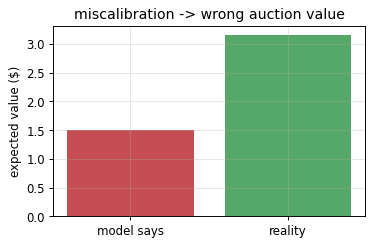

In [13]:
# find a bucket where the model is clearly off and show the dollar consequence
xs, ys, counts = reliability(raw, y[te])
i = int(np.argmax(np.abs(ys - xs)))          # the most miscalibrated bucket
bid = 10.0
print(f"impressions the model scored ~{xs[i]:.2f}:")
print(f"  model says value = pCTR x bid = {xs[i]:.2f} x ${bid:.0f} = ${xs[i]*bid:.2f}")
print(f"  reality          =            = {ys[i]:.2f} x ${bid:.0f} = ${ys[i]*bid:.2f}")
plt.figure(figsize=(4.5,3))
plt.bar(["model says", "reality"], [xs[i]*bid, ys[i]*bid], color=[RED, GREEN])
plt.ylabel("expected value ($)"); plt.title("miscalibration -> wrong auction value"); plt.show()

## Step 7 · Fix #1 — **Platt scaling** (a sigmoid correction)

The fix: learn a correction on a **held-out calibration set** (never the training data).
**Platt scaling** fits a small logistic regression that maps the raw score to an honest
probability: `p = sigmoid(a·score + b)`. It's just two numbers (`a`, `b`), so it's stable
even with little data — but it assumes the correction is a smooth S-shape.

In [15]:
from sklearn.linear_model import LogisticRegression
platt = LogisticRegression().fit(raw_cal.reshape(-1,1), y[cal])   # learn a, b on the CAL set
p_platt = platt.predict_proba(raw.reshape(-1,1))[:, 1]            # apply to the test scores
print("a =", round(platt.coef_[0,0],2), " b =", round(platt.intercept_[0],2))
print("ECE   raw:", round(ece(raw, y[te]),3), "->  Platt:", round(ece(p_platt, y[te]),3))
print("AUC   raw:", round(roc_auc_score(y[te], raw),3), "->  Platt:", round(roc_auc_score(y[te], p_platt),3), "(ranking unchanged)")

a = 2.59  b = -1.15
ECE   raw: 0.127 ->  Platt: 0.037
AUC   raw: 0.724 ->  Platt: 0.724 (ranking unchanged)


## Step 8 · Fix #2 — **Isotonic** calibration (a flexible staircase)

**Isotonic regression** fits a flexible **monotone step function** instead of a fixed
S-shape. It can correct any monotone distortion, so it's more powerful — but it needs
**more** calibration data or it overfits into a jagged staircase. Use Platt with little
data, isotonic with plenty.

In [17]:
from sklearn.isotonic import IsotonicRegression
iso = IsotonicRegression(out_of_bounds="clip").fit(raw_cal, y[cal])
p_iso = iso.predict(raw)
print("ECE   raw:", round(ece(raw, y[te]),3),
      " Platt:", round(ece(p_platt, y[te]),3),
      " Isotonic:", round(ece(p_iso, y[te]),3))

ECE   raw: 0.127  Platt: 0.037  Isotonic: 0.023


## Step 9 · Before vs after — the payoff

All three reliability curves together. Both corrections pull the dots onto the diagonal
(honest), and the **AUC table proves the ranking was not harmed** — calibration only fixed
the *numbers*, not the *order*.

Platt vs isotonic: Platt = smooth S-curve, few params, good with little data;
isotonic = flexible staircase, needs more data, can overfit tiny calibration sets.


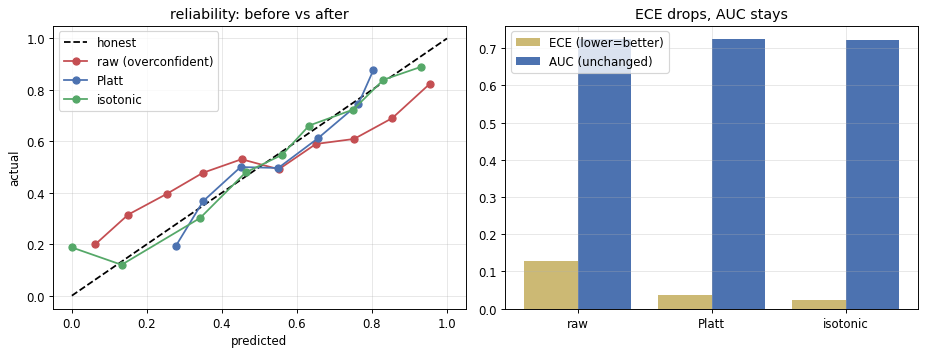

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ax[0].plot([0,1],[0,1], "k--", label="honest")
for p, name, c in [(raw,"raw (overconfident)",RED), (p_platt,"Platt",BLUE), (p_iso,"isotonic",GREEN)]:
    xs, ys, _ = reliability(p, y[te]); ax[0].plot(xs, ys, "o-", color=c, label=name)
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual"); ax[0].legend(); ax[0].set_title("reliability: before vs after")

names = ["raw", "Platt", "isotonic"]
eces = [ece(raw,y[te]), ece(p_platt,y[te]), ece(p_iso,y[te])]
aucs = [roc_auc_score(y[te],raw), roc_auc_score(y[te],p_platt), roc_auc_score(y[te],p_iso)]
xb = np.arange(3)
ax[1].bar(xb-0.2, eces, 0.4, color=GOLD, label="ECE (lower=better)")
ax[1].bar(xb+0.2, aucs, 0.4, color=BLUE, label="AUC (unchanged)")
ax[1].set_xticks(xb); ax[1].set_xticklabels(names); ax[1].legend(); ax[1].set_title("ECE drops, AUC stays")
plt.show()
print("Platt vs isotonic: Platt = smooth S-curve, few params, good with little data;")
print("isotonic = flexible staircase, needs more data, can overfit tiny calibration sets.")

---
# Part B · Class imbalance

## Step 10 · Make a **rare-positive** dataset

Clicks are rare. We build data where only about **3%** of impressions are positive — and
immediately hit the trap.

positive (click) rate: 0.033  -> very imbalanced


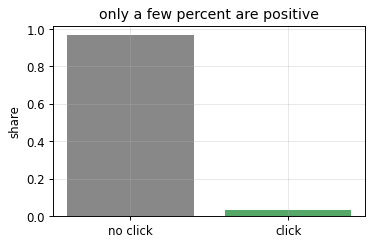

In [22]:
rng2 = np.random.default_rng(1)
M = 20000
f1, f2 = rng2.uniform(0,1,M), rng2.uniform(0,1,M)
p_pos = 1 / (1 + np.exp(-(-6.4 + 3.0*f1 + 2.0*f2)))    # rare positives
yb = (rng2.random(M) < p_pos).astype(int)
Xb = np.c_[f1, f2]
t, v = slice(0, 15000), slice(15000, M)
print("positive (click) rate:", round(yb.mean(), 3), " -> very imbalanced")
plt.figure(figsize=(4.5,3)); plt.bar(["no click","click"], [ (yb==0).mean(), yb.mean() ], color=[GRAY, GREEN])
plt.ylabel("share"); plt.title("only a few percent are positive"); plt.show()

## Step 11 · The accuracy trap — a "model" that does nothing looks great

Train a normal model and look at **accuracy**. Because positives are rare, a model that
basically predicts "no click" for everyone scores high accuracy — but its **recall**
(fraction of real clicks it catches) is near **zero**. Accuracy is the wrong metric here.

In [24]:
from sklearn.metrics import recall_score, average_precision_score, accuracy_score
naive = LogisticRegression().fit(Xb[t], yb[t])
pv = naive.predict_proba(Xb[v])[:, 1]
pred_label = (pv > 0.5).astype(int)
print("accuracy:", round(accuracy_score(yb[v], pred_label), 3), " <- looks amazing")
print("recall  :", round(recall_score(yb[v], pred_label), 3), " <- but it catches almost NO real clicks")
print("(a do-nothing 'always no' model would score accuracy", round((yb[v]==0).mean(),3), "too)")

accuracy: 0.965  <- looks amazing
recall  : 0.0  <- but it catches almost NO real clicks
(a do-nothing 'always no' model would score accuracy 0.965 too)


## Step 12 · Use honest metrics — PR-AUC and recall

For rare positives, use **precision-recall AUC** (PR-AUC) and **recall at your threshold**,
not accuracy. The precision-recall curve shows the trade-off; PR-AUC summarizes it (higher
is better; a random model scores about the positive rate).

PR-AUC: 0.12  (random baseline ~ 0.035 )


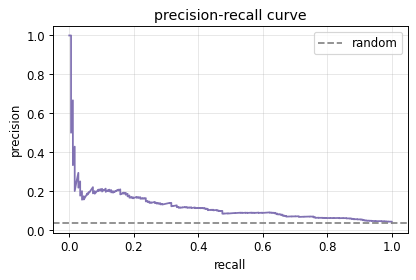

In [26]:
from sklearn.metrics import precision_recall_curve
prec, rec, _ = precision_recall_curve(yb[v], pv)
print("PR-AUC:", round(average_precision_score(yb[v], pv), 3), " (random baseline ~", round(yb[v].mean(),3), ")")
plt.figure(figsize=(5,3.4)); plt.plot(rec, prec, color=PURPLE)
plt.axhline(yb[v].mean(), color=GRAY, ls="--", label="random")
plt.xlabel("recall"); plt.ylabel("precision"); plt.legend(); plt.title("precision-recall curve"); plt.show()

## Step 13 · Fix — **class weights** (make rare positives count more)

The simplest fix: tell the model each positive is worth many negatives, so ignoring them
costs a lot of loss. In scikit-learn that's `class_weight="balanced"`. Recall jumps.

recall  @0.5  ->  naive: 0.0  weighted: 0.706


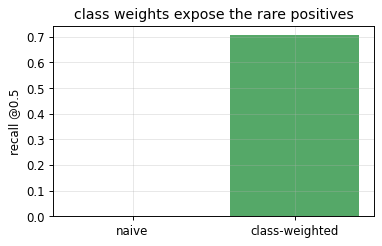

In [28]:
weighted = LogisticRegression(class_weight="balanced").fit(Xb[t], yb[t])
pw = weighted.predict_proba(Xb[v])[:, 1]
print("recall  @0.5  ->  naive:", round(recall_score(yb[v], pv>0.5),3),
      " weighted:", round(recall_score(yb[v], pw>0.5),3))
plt.figure(figsize=(4.6,3))
plt.bar(["naive","class-weighted"], [recall_score(yb[v], pv>0.5), recall_score(yb[v], pw>0.5)], color=[GRAY, GREEN])
plt.ylabel("recall @0.5"); plt.title("class weights expose the rare positives"); plt.show()

## Step 14 · **Focal loss** — the idea, visualized

Focal loss is another lever: it **down-weights easy examples** so training focuses on the
hard, confusing ones. The factor is $(1-p_t)^\gamma$, where $p_t$ is the probability the
model gave the *true* class. An easy example (high $p_t$) gets a tiny weight; a hard one
(low $p_t$) keeps almost full weight. We plot that factor so you can see it.

gamma=0 -> ordinary loss (all equal). Bigger gamma -> easy examples fade, hard ones dominate.


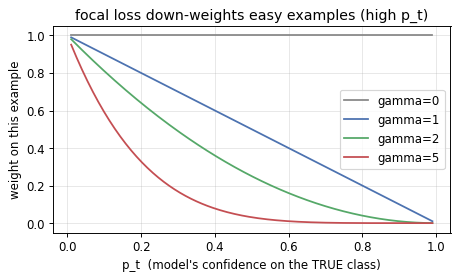

In [30]:
pt = np.linspace(0.01, 0.99, 200)
plt.figure(figsize=(5.5,3.4))
for gamma, c in [(0, GRAY), (1, BLUE), (2, GREEN), (5, RED)]:
    plt.plot(pt, (1-pt)**gamma, color=c, label=f"gamma={gamma}")
plt.xlabel("p_t  (model's confidence on the TRUE class)"); plt.ylabel("weight on this example")
plt.title("focal loss down-weights easy examples (high p_t)"); plt.legend(); plt.show()
print("gamma=0 -> ordinary loss (all equal). Bigger gamma -> easy examples fade, hard ones dominate.")

## Step 15 · **Resampling** — and why it then needs recalibration

Another fix is to **oversample** positives until the training set is balanced. It helps the
model learn the boundary, but it **changes the prior**: the model now thinks positives are
common, so its raw probabilities come out **way too high**. You must **recalibrate** on
real-rate data before using the numbers. We show the inflation, then fix it with Part A's
Platt scaling.

true positive rate: 0.035
mean predicted prob after oversampling: 0.407  <- inflated ~ 11.5 x
mean predicted prob after recalibration: 0.035  <- back near the true rate


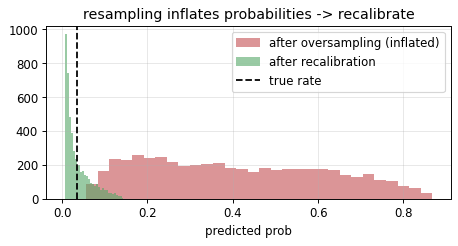

In [32]:
# oversample positives in the training set to ~50/50
pos = np.where(yb[t]==1)[0]; neg = np.where(yb[t]==0)[0]
pos_os = rng2.choice(pos, size=len(neg), replace=True)      # duplicate positives up to #negatives
idx = np.concatenate([neg, pos_os]); rng2.shuffle(idx)
resampled = LogisticRegression().fit(Xb[t][idx], yb[t][idx])
p_res = resampled.predict_proba(Xb[v])[:, 1]
print("true positive rate:", round(yb[v].mean(),3))
print("mean predicted prob after oversampling:", round(p_res.mean(),3), " <- inflated ~", round(p_res.mean()/yb[v].mean(),1), "x")

# recalibrate back to the real rate with Platt (fit on a real-rate slice)
recal = LogisticRegression().fit(p_res.reshape(-1,1), yb[v])   # (demo: fit on real-rate data)
p_fixed = recal.predict_proba(p_res.reshape(-1,1))[:,1]
print("mean predicted prob after recalibration:", round(p_fixed.mean(),3), " <- back near the true rate")
plt.figure(figsize=(5.5,3))
plt.hist(p_res, bins=30, alpha=.6, color=RED, label="after oversampling (inflated)")
plt.hist(p_fixed, bins=30, alpha=.6, color=GREEN, label="after recalibration")
plt.axvline(yb[v].mean(), color="k", ls="--", label="true rate")
plt.legend(); plt.title("resampling inflates probabilities -> recalibrate"); plt.xlabel("predicted prob"); plt.show()

---
# Part C · Sparse slices & delayed feedback

## Step 16 · Sparse slices — don't trust a tiny group's raw rate

Calibration can be great overall but wrong on a small **slice** (one country, a new
advertiser). If a slice has **2 clicks in 20 impressions**, its observed rate is 10% — but
with only 20 samples that's noisy. The fix is **shrinkage**: pull the tiny slice's estimate
toward the global rate, trusting it more as it gets more data:
$$\hat p_{\text{slice}}=\frac{n\cdot\bar p_{\text{slice}} + m\cdot p_{\text{global}}}{n+m}$$

slice with   2 clicks /    20 imps: raw 0.100 -> shrunk 0.064
slice with  30 clicks /   500 imps: raw 0.060 -> shrunk 0.059
slice with 900 clicks / 20000 imps: raw 0.045 -> shrunk 0.045


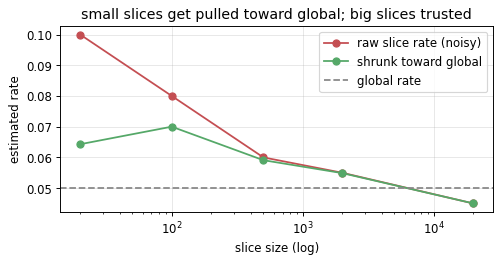

In [35]:
global_rate = 0.05
def shrink(clicks, imps, m=50, glob=global_rate):
    return (clicks + m*glob) / (imps + m)

for clicks, imps in [(2, 20), (30, 500), (900, 20000)]:
    raw_rate = clicks/imps
    print(f"slice with {clicks:>3} clicks / {imps:>5} imps: raw {raw_rate:.3f} -> shrunk {shrink(clicks,imps):.3f}")

sizes = [20, 100, 500, 2000, 20000]
raws  = [2/20, 8/100, 30/500, 110/2000, 900/20000]   # noisy small slices, steadier big ones
shr   = [shrink(r*n, n) for r, n in zip(raws, sizes)]
plt.figure(figsize=(6,3.2))
plt.plot(sizes, raws, "o-", color=RED, label="raw slice rate (noisy)")
plt.plot(sizes, shr, "o-", color=GREEN, label="shrunk toward global")
plt.axhline(global_rate, color=GRAY, ls="--", label="global rate")
plt.xscale("log"); plt.xlabel("slice size (log)"); plt.ylabel("estimated rate"); plt.legend()
plt.title("small slices get pulled toward global; big slices trusted"); plt.show()

## Step 17 · Delayed feedback — fresh data looks falsely negative

A click or conversion can arrive **hours later**. If you check labels *now*, recent
impressions look like "no click" only because the click **hasn't happened yet**. Training
on those biases probabilities **downward** for fresh cohorts. The fix (same as leakage): use
an **attribution window** and **exclude** rows whose window hasn't elapsed ("censored").

young impressions: observed rate far below the eventual rate -> exclude censored rows or model the delay.


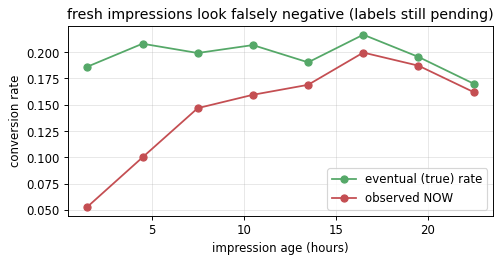

In [37]:
# each impression eventually converts with prob 0.20, but the click arrives after a random delay
rng3 = np.random.default_rng(5)
K = 4000
age_hours = rng3.uniform(0, 24, K)                 # how long ago the impression happened
will_convert = rng3.random(K) < 0.20
delay = rng3.exponential(6, K)                     # click arrives this many hours after impression
observed_now = will_convert & (delay <= age_hours) # only counts if the click already arrived

# observed conversion rate by how fresh the impression is
bins = np.linspace(0, 24, 9)
obs, true = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (age_hours>=lo) & (age_hours<hi)
    obs.append(observed_now[m].mean()); true.append(will_convert[m].mean())
centers = (bins[:-1]+bins[1:])/2
plt.figure(figsize=(6,3.2))
plt.plot(centers, true, "o-", color=GREEN, label="eventual (true) rate")
plt.plot(centers, obs, "o-", color=RED, label="observed NOW")
plt.xlabel("impression age (hours)"); plt.ylabel("conversion rate"); plt.legend()
plt.title("fresh impressions look falsely negative (labels still pending)"); plt.show()
print("young impressions: observed rate far below the eventual rate -> exclude censored rows or model the delay.")

---
## Recap — the M8 toolkit

**Calibration (Part A).** A model can *rank* perfectly yet *lie* about probabilities.
Check it with a **reliability diagram** and one number, **ECE**. Fix it on a held-out set
with **Platt** (smooth S-curve, little data) or **isotonic** (flexible staircase, more
data). Calibration lowers ECE while leaving AUC unchanged — and it's what makes
`pCTR × bid` trustworthy.

**Class imbalance (Part B).** With rare positives, **accuracy lies** — use **PR-AUC** and
**recall**. Expose the rare class with **class weights** or **focal loss** (down-weights
easy examples); **resampling** works too but **changes the prior**, so **recalibrate**
afterward.

**Sparse slices & delayed feedback (Part C).** Don't trust a tiny slice's raw rate — **shrink**
it toward the global rate. And remember fresh data looks **falsely negative** because labels
are still arriving — use an **attribution window** and drop censored rows.

**Where this connects:** M8 is the safety layer on top of the M7 ranker — it makes the
probabilities honest before they hit the auction. Next, M9 handles brand-new items/users
(cold-start), and M10 handles the messy implicit labels these systems learn from.